In [71]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots



In [72]:
output_dir = '/home/slim/dpo-rhlf-paraphrase-types/out/plots'
plt.style.use(['science','no-latex'])

textwidth = 3.31314 #twocolumn
textwidth = 5.90666 #onecolumn
aspect_ratio = (5 ** 0.5 - 1) / 2 # golden ratio
scale = 1.0
width = textwidth * scale
height = width * aspect_ratio

# Results
## Effectiveness of DPO and RHLF in Paraphrase Generation

In [73]:
# Load the new JSON data
file_path_apt = '/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-15-07-48-34036765.json'

# Read and parse the JSON file
with open(file_path_apt, 'r') as file:
    data_apt = json.load(file)

# Extract relevant information for APT (kind and count of "Yes" for APT)
apt_accuracies = {
    "etpc_model": 0,
    "base_model": 0,
    "dpo_model": 0
}
apt_counts = {
    "etpc_model": 0,
    "base_model": 0,
    "dpo_model": 0
}

# Loop through the data and gather counts for APT being "Yes"
for item in data_apt:
    if 'APT' in item and 'Kind' in item:
        model = item['Kind']
        if model in apt_accuracies:
            if item['APT'] == 'Yes':
                apt_accuracies[model] += 1
            apt_counts[model] += 1

# Calculate the percentage of APT "Yes" for each model
apt_percentages = {
    model: (apt_accuracies[model] / apt_counts[model] * 100) if apt_counts[model] > 0 else 0
    for model in apt_accuracies
}

apt_percentages


{'etpc_model': 11.827956989247312,
 'base_model': 12.376237623762377,
 'dpo_model': 35.26315789473684}

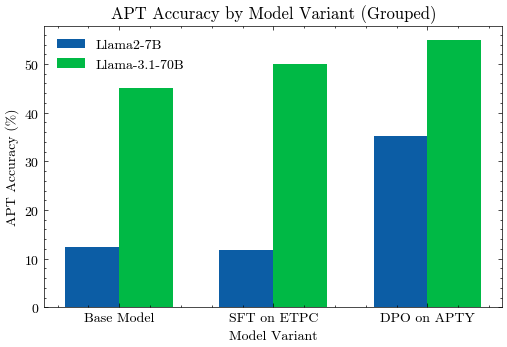

In [84]:
# Data for the grouped bar chart
group_labels = ['Base Model', 'SFT on ETPC', 'DPO on APTY']
llama2_accuracies = [
    apt_percentages["base_model"],
    apt_percentages["etpc_model"],
    apt_percentages["dpo_model"],
]
llama3_accuracies = [
    45.0,
    50,
    55
]

# Define positions for groups
bar_width = 0.35
index = np.arange(len(group_labels))

# Create the grouped bar chart
plt.style.use(['science','no-latex'])
plt.figure(figsize=(width, height))

plt.bar(index, llama2_accuracies, bar_width, label='Llama2-7B')
plt.bar(index + bar_width, llama3_accuracies, bar_width, label='Llama-3.1-70B')

# Add labels and title with a more formal style
plt.xlabel('Model Variant', fontsize=10)
plt.ylabel('APT Accuracy (%)', fontsize=10)
plt.title('APT Accuracy by Model Variant (Grouped)', fontsize=12)

# Add group labels to x-axis
plt.xticks(index + bar_width / 2, group_labels, fontsize=10)

# Add a legend with a formal appearance
plt.legend(fontsize=10)

# Adjust the layout for a professional look
#plt.tight_layout()

output_path = os.path.join(output_dir, "apt_accuracies.pdf")
plt.savefig(output_path, dpi=300)

# Display the updated plot
plt.show()

## Incorporating Human-Ranked Data for Improved Paraphrase Generation

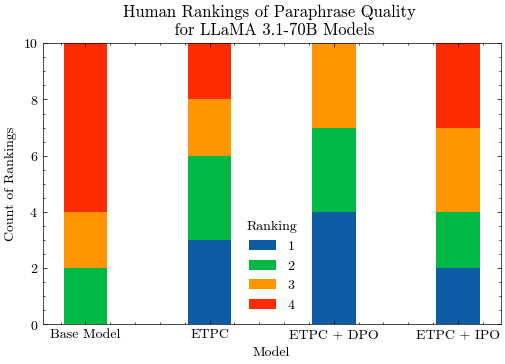

In [94]:
# Adding the base model rankings to the dummy data
data_with_base = {
    "Base Model": [4, 4, 4, 2, 4, 4, 3, 4, 2, 3],
    "ETPC": [1, 2, 3, 1, 2, 3, 4, 2, 1, 4],
    "ETPC + DPO": [2, 1, 1, 3, 3, 2, 2, 1, 3, 1],
    "ETPC + IPO": [3, 3, 2, 4, 1, 4, 1, 3, 4, 2]
}

# Convert updated data to a DataFrame
df_with_base = pd.DataFrame(data_with_base)

# Count how often each model got each ranking (1 to 4)
rank_counts_with_base = df_with_base.apply(lambda col: col.value_counts()).fillna(0).astype(int)

# Transpose for better plotting (stacked bar chart)
rank_counts_with_base = rank_counts_with_base.transpose()

# Plot the stacked bar chart with the base model
plt.style.use(['science','no-latex'])
# Set figure size
fig, ax = plt.subplots(figsize=(width, height))

index = range(len(rank_counts_with_base))

for i, col in enumerate(rank_counts_with_base.columns):
    ax.bar(index, rank_counts_with_base[col], bar_width, bottom=rank_counts_with_base.iloc[:, :i].sum(axis=1))

# Set x-tick labels to the model names
ax.set_xticks(index)
ax.set_xticklabels(rank_counts_with_base.index, fontsize=10)


# Add labels and title
ax.set_xlabel('Model', fontsize=10)
ax.set_ylabel('Count of Rankings', fontsize=10)
ax.set_title('Human Rankings of Paraphrase Quality \n for LLaMA 3.1-70B Models', fontsize=12)


# Add legend
ax.legend(rank_counts_with_base.columns, title="Ranking", frameon=False, fontsize=10)

output_path = os.path.join(output_dir, "apt_ranking.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()
